In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [2]:
import pandas as pd

df_energy = pd.read_excel(
    r"C:\Users\user\internship 1 month\infosys internsip\cleaned_sorted_energy_dataset.xlsx"
)

df_energy.columns = df_energy.columns.str.strip()
df_energy.columns


Index(['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Hour', 'Date',
       'Outdoor Temperature (C)', 'Season', 'Household Size', 'Month'],
      dtype='object')

In [3]:
df_energy.columns = df_energy.columns.str.strip()

df_energy['hour'] = df_energy['Hour']
df_energy['day'] = pd.to_datetime(df_energy['Date']).dt.day
df_energy['weekday'] = pd.to_datetime(df_energy['Date']).dt.weekday
df_energy['month'] = df_energy['Month']


In [4]:
df_energy['lag_1'] = df_energy.groupby('Appliance Type')['Energy Consumption (kWh)'].shift(1)
df_energy['lag_24'] = df_energy.groupby('Appliance Type')['Energy Consumption (kWh)'].shift(24)

df_energy['rolling_mean_24'] = (
    df_energy.groupby('Appliance Type')['Energy Consumption (kWh)']
    .transform(lambda x: x.rolling(24).mean().shift(1))
)

df_energy.dropna(inplace=True)


In [6]:
appliance_data = {}

for appliance in df_energy['Appliance Type'].unique():
    df_a = df_energy[df_energy['Appliance Type'] == appliance]

    X = df_a[['hour','day','weekday','month',
              'Outdoor Temperature (C)','Household Size',
              'lag_1','lag_24','rolling_mean_24']]
    
    y = df_a['Energy Consumption (kWh)']

    appliance_data[appliance] = {'X': X, 'y': y}



In [7]:
X_train_data, X_test_data = {}, {}
y_train_data, y_test_data = {}, {}

for appliance, data in appliance_data.items():
    X, y = data['X'], data['y']
    split = int(len(X) * 0.8)

    X_train_data[appliance] = X.iloc[:split]
    X_test_data[appliance] = X.iloc[split:]
    y_train_data[appliance] = y.iloc[:split]
    y_test_data[appliance] = y.iloc[split:]


In [8]:
import os

output_dir = r"C:\Users\user\internship 1 month\infosys internsip\processed_appliance_data"
os.makedirs(output_dir, exist_ok=True)

for appliance in X_train_data.keys():
    name = appliance.replace(" ", "_")

    X_train_data[appliance].to_csv(f"{output_dir}/X_train_{name}.csv", index=False)
    X_test_data[appliance].to_csv(f"{output_dir}/X_test_{name}.csv", index=False)
    y_train_data[appliance].to_csv(f"{output_dir}/y_train_{name}.csv", index=False)
    y_test_data[appliance].to_csv(f"{output_dir}/y_test_{name}.csv", index=False)


In [9]:
import pandas as pd
import os

base_path = r"C:\Users\user\internship 1 month\infosys internsip\processed_appliance_data"

appliance = "Air_Conditioning"

X_train = pd.read_csv(os.path.join(base_path, f"X_train_{appliance}.csv"))
X_test  = pd.read_csv(os.path.join(base_path, f"X_test_{appliance}.csv"))
y_train = pd.read_csv(os.path.join(base_path, f"y_train_{appliance}.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(base_path, f"y_test_{appliance}.csv")).squeeze()


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [11]:
y_pred = model.predict(X_test)


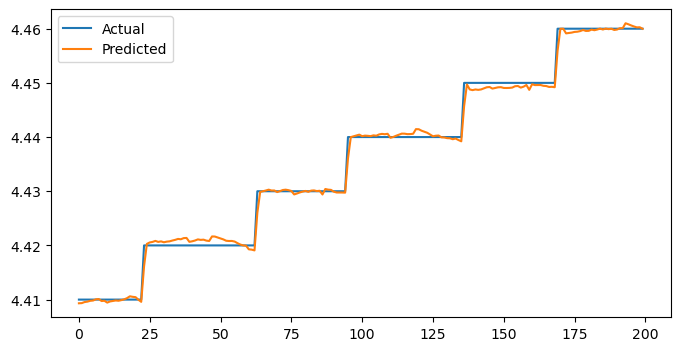

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.show()
